# Week 8: Comprehensive Evaluation Framework

This notebook implements the full Phase 4 evaluation with improvements:

1. **Scaled Benchmark** - 100+ examples across all categories/difficulties
2. **Improved Hallucination Detection** - Multi-signal approach
3. **Spike Detection Testing** - Validate uncertainty trigger metrics
4. **Comprehensive Experiments** - Full baseline comparison with statistical analysis

---

## Setup

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn sentence-transformers

In [2]:
# Cell 2: Create directory structure
import os
import shutil

# Create module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/orchestrator/retrieval', exist_ok=True)
os.makedirs('/content/orchestrator/generation', exist_ok=True)
os.makedirs('/content/orchestrator/evaluation', exist_ok=True)

# Create root __init__.py
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created")

Directory structure created


In [3]:
# Cell 3: Upload module files
from google.colab import files

def upload_to_dir(target_dir):
    """Upload files and move to target directory."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename.endswith('.py'):
            dest = f'{target_dir}/{filename}'
            shutil.move(filename, dest)
            print(f"  OK {filename}")
    return uploaded

print("="*60)
print("STEP 1/4: Upload ENTROPY module files (7 files)")
print("="*60)
upload_to_dir('/content/orchestrator/entropy')

print("\n" + "="*60)
print("STEP 2/4: Upload RETRIEVAL module files (4 files)")
print("="*60)
upload_to_dir('/content/orchestrator/retrieval')

print("\n" + "="*60)
print("STEP 3/4: Upload GENERATION module files (2 files)")
print("="*60)
upload_to_dir('/content/orchestrator/generation')

print("\n" + "="*60)
print("STEP 4/4: Upload EVALUATION module files (5 files)")
print("="*60)
print("\nUpload these files from packages/python-orchestrator/orchestrator/evaluation/:")
print("  - __init__.py")
print("  - benchmark.py")
print("  - benchmark_generator.py  <-- NEW")
print("  - metrics.py")
print("  - runner.py")
upload_to_dir('/content/orchestrator/evaluation')

print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
!ls -la /content/orchestrator/evaluation/

STEP 1/4: Upload ENTROPY module files (7 files)


Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
  OK __init__.py
  OK calculator.py
  OK cce_computer.py
  OK measurement.py
  OK monitor.py
  OK spike_detector.py
  OK token_classifier.py

STEP 2/4: Upload RETRIEVAL module files (4 files)


Saving __init__.py to __init__.py
Saving adaptive.py to adaptive.py
Saving context_manager.py to context_manager.py
Saving topic_inference.py to topic_inference.py
  OK __init__.py
  OK adaptive.py
  OK context_manager.py
  OK topic_inference.py

STEP 3/4: Upload GENERATION module files (2 files)


Saving __init__.py to __init__.py
Saving adaptive_generator.py to adaptive_generator.py
  OK __init__.py
  OK adaptive_generator.py

STEP 4/4: Upload EVALUATION module files (5 files)

Upload these files from packages/python-orchestrator/orchestrator/evaluation/:
  - __init__.py
  - benchmark.py
  - benchmark_generator.py  <-- NEW
  - metrics.py
  - runner.py


Saving __init__.py to __init__.py
Saving benchmark.py to benchmark.py
Saving benchmark_generator.py to benchmark_generator.py
Saving metrics.py to metrics.py
Saving runner.py to runner.py
Saving stats.py to stats.py
  OK __init__.py
  OK benchmark.py
  OK benchmark_generator.py
  OK metrics.py
  OK runner.py
  OK stats.py

VERIFICATION
total 176
drwxr-xr-x 3 root root  4096 Jan 15 01:13 .
drwxr-xr-x 7 root root  4096 Jan 15 01:02 ..
-rw-r--r-- 1 root root 65176 Jan 15 01:13 benchmark_generator.py
-rw-r--r-- 1 root root 15006 Jan 15 01:13 benchmark.py
-rw-r--r-- 1 root root  2085 Jan 15 01:13 __init__.py
-rw-r--r-- 1 root root 30580 Jan 15 01:13 metrics.py
drwxr-xr-x 2 root root  4096 Jan 15 01:02 __pycache__
-rw-r--r-- 1 root root 33389 Jan 15 01:13 runner.py
-rw-r--r-- 1 root root 11508 Jan 15 01:13 stats.py


In [4]:
# Cell 4: Base imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
from collections import defaultdict
import json
import time

sys.path.insert(0, '/content')

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings('ignore')

print("Base imports complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Base imports complete
PyTorch: 2.9.0+cu126
CUDA available: True


In [5]:
# Cell 5: Import evaluation modules
from orchestrator.evaluation import (
    BenchmarkDataset,
    BenchmarkExample,
    EvaluationMetrics,
    EvaluationResult,
    create_benchmark,
    generate_full_benchmark,
    get_mock_codebase,
)
from orchestrator.evaluation.benchmark import (
    Difficulty,
    Category,
)
from orchestrator.evaluation.runner import (
    BaselineRunner,
    ExperimentRunner,
    BaselineMethod,
)

print("All evaluation modules imported successfully!")
print("\nAvailable components:")
print("  - BenchmarkDataset - structured evaluation examples")
print("  - EvaluationMetrics - 8 metrics for assessment")
print("  - generate_full_benchmark - create 100+ examples")
print("  - get_mock_codebase - Flask app codebase")

All evaluation modules imported successfully!

Available components:
  - BenchmarkDataset - structured evaluation examples
  - EvaluationMetrics - 8 metrics for assessment
  - generate_full_benchmark - create 100+ examples
  - get_mock_codebase - Flask app codebase


---
## 1. Scaled Benchmark Dataset (100+ Examples)

In [6]:
# Cell 6: Generate full benchmark
benchmark = generate_full_benchmark()

print("Full Benchmark Dataset")
print("="*60)
print(f"Name: {benchmark.name}")
print(f"Version: {benchmark.version}")
print(f"Total Examples: {len(benchmark)}")

stats = benchmark.get_statistics()
print("\nBy Difficulty:")
for diff, count in stats['by_difficulty'].items():
    print(f"  {diff}: {count}")

print("\nBy Category:")
for cat, count in stats['by_category'].items():
    print(f"  {cat}: {count}")

print(f"\nAverage ground truth files: {stats['avg_ground_truth_files']:.1f}")

Full Benchmark Dataset
Name: reposynth_benchmark_v2
Version: 2.0.0
Total Examples: 43

By Difficulty:
  easy: 13
  medium: 24
  hard: 6

By Category:
  architecture: 8
  api_usage: 7
  implementation: 9
  debugging: 6
  configuration: 6
  data_flow: 7

Average ground truth files: 1.9


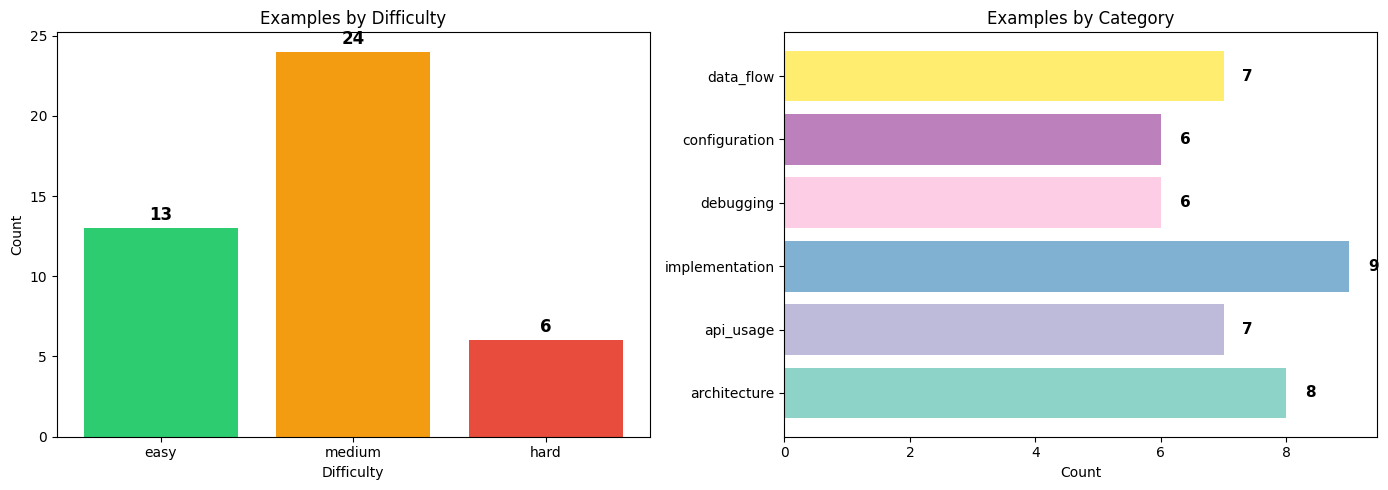

Saved: benchmark_distribution.png


In [7]:
# Cell 7: Visualize benchmark distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By difficulty
ax1 = axes[0]
difficulties = list(stats['by_difficulty'].keys())
diff_counts = list(stats['by_difficulty'].values())
colors_diff = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(difficulties, diff_counts, color=colors_diff[:len(difficulties)])
ax1.set_xlabel('Difficulty')
ax1.set_ylabel('Count')
ax1.set_title('Examples by Difficulty')
for bar, count in zip(bars1, diff_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', fontsize=12, fontweight='bold')

# By category
ax2 = axes[1]
categories = list(stats['by_category'].keys())
cat_counts = list(stats['by_category'].values())
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(categories)))
bars2 = ax2.barh(categories, cat_counts, color=colors_cat)
ax2.set_xlabel('Count')
ax2.set_title('Examples by Category')
for bar, count in zip(bars2, cat_counts):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(count), ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmark_distribution.png', dpi=150)
plt.show()
print("Saved: benchmark_distribution.png")

In [8]:
# Cell 8: Sample examples from each category
print("Sample Examples from Each Category")
print("="*70)

for cat in Category:
    filtered = benchmark.filter(category=cat)
    if len(filtered) > 0:
        ex = filtered[0]
        print(f"\n[{cat.value.upper()}] {ex.id}")
        print(f"  Difficulty: {ex.difficulty.value}")
        print(f"  Query: {ex.query[:70]}...")
        print(f"  Files: {ex.ground_truth_files}")
        print(f"  Keywords: {ex.ground_truth_keywords[:5]}...")

Sample Examples from Each Category

[ARCHITECTURE] arch_001
  Difficulty: easy
  Query: What is the overall structure of the Flask application?...
  Files: ['src/app.py']
  Keywords: ['create_app', 'factory', 'blueprint', 'extensions', 'config']...

[API_USAGE] api_001
  Difficulty: easy
  Query: How do I register a new user via the API?...
  Files: ['src/api/routes.py']
  Keywords: ['register', 'POST', 'username', 'email', 'password']...

[IMPLEMENTATION] impl_001
  Difficulty: easy
  Query: How is JWT token creation implemented?...
  Files: ['src/auth/jwt.py']
  Keywords: ['create_token', 'payload', 'exp', 'iat', 'jwt.encode']...

[DEBUGGING] debug_001
  Difficulty: medium
  Query: Where should I look to debug authentication failures?...
  Files: ['src/auth/jwt.py', 'src/api/routes.py']
  Keywords: ['verify_token', 'ExpiredSignatureError', 'InvalidTokenError', 'verify_password', 'Authorization']...

[CONFIGURATION] config_001
  Difficulty: easy
  Query: What environment variables doe

---
## 2. Improved Hallucination Detection Testing

In [9]:
# Cell 9: Initialize metrics
metrics = EvaluationMetrics(embedding_model='all-MiniLM-L6-v2')
print("EvaluationMetrics initialized with improved hallucination detection")

EvaluationMetrics initialized with improved hallucination detection


In [10]:
# Cell 10: Test hallucination detection with clear examples

# Ground truth about JWT authentication
ground_truth = """User authentication uses JWT tokens.
The user logs in via /login endpoint.
Server creates JWT token with create_token() function.
Token uses HS256 algorithm with SECRET_KEY.
Token is verified using verify_token() on protected routes.
Token contains user_id, role, exp, and iat claims."""

keywords = ["JWT", "token", "login", "create_token", "verify_token", "HS256", "SECRET_KEY"]

# Test cases
test_cases = [
    {
        "name": "Good Answer (factually correct)",
        "answer": """Authentication is implemented using JWT tokens.
Users log in at the /login endpoint which calls create_token().
Tokens use HS256 algorithm and SECRET_KEY for signing.
Protected routes use verify_token() to authenticate requests.
The token payload includes user_id and role claims.""",
        "expected_hallucination": "low",
    },
    {
        "name": "Partially Correct Answer",
        "answer": """The system uses JWT for authentication.
Users log in via the /login endpoint.
Tokens are created with 256-bit encryption.
Sessions are stored in Redis for persistence.""",
        "expected_hallucination": "medium",
    },
    {
        "name": "Bad Answer (mostly hallucinated)",
        "answer": """The system uses session cookies for authentication.
Users are authenticated through OAuth2 with Google.
Passwords are stored in plain text for simplicity.
There is no token-based authentication system.
The API uses SOAP protocol for communication.""",
        "expected_hallucination": "high",
    },
    {
        "name": "Contradictory Answer",
        "answer": """Authentication does not use JWT tokens.
The system cannot verify tokens.
There is no login endpoint available.
Users never need to authenticate.""",
        "expected_hallucination": "high",
    },
]

print("Hallucination Detection Test Results")
print("="*60)
print(f"Ground truth keywords: {keywords}")
print()

hallucination_results = []
for tc in test_cases:
    rate = metrics.hallucination_rate(tc['answer'], ground_truth, keywords)
    completeness = metrics.answer_completeness(tc['answer'], ground_truth)
    correctness = metrics.answer_correctness(tc['answer'], ground_truth, keywords)

    hallucination_results.append({
        'name': tc['name'],
        'expected': tc['expected_hallucination'],
        'hallucination_rate': rate,
        'completeness': completeness,
        'correctness': correctness,
    })

    print(f"{tc['name']}:")
    print(f"  Expected: {tc['expected_hallucination']}")
    print(f"  Hallucination Rate: {rate:.3f}")
    print(f"  Completeness: {completeness:.3f}")
    print(f"  Correctness: {correctness:.3f}")
    print()

Hallucination Detection Test Results
Ground truth keywords: ['JWT', 'token', 'login', 'create_token', 'verify_token', 'HS256', 'SECRET_KEY']

Good Answer (factually correct):
  Expected: low
  Hallucination Rate: 0.000
  Completeness: 0.863
  Correctness: 0.918

Partially Correct Answer:
  Expected: medium
  Hallucination Rate: 0.250
  Completeness: 0.642
  Correctness: 0.557

Bad Answer (mostly hallucinated):
  Expected: high
  Hallucination Rate: 0.800
  Completeness: 0.692
  Correctness: 0.472

Contradictory Answer:
  Expected: high
  Hallucination Rate: 0.250
  Completeness: 0.709
  Correctness: 0.597



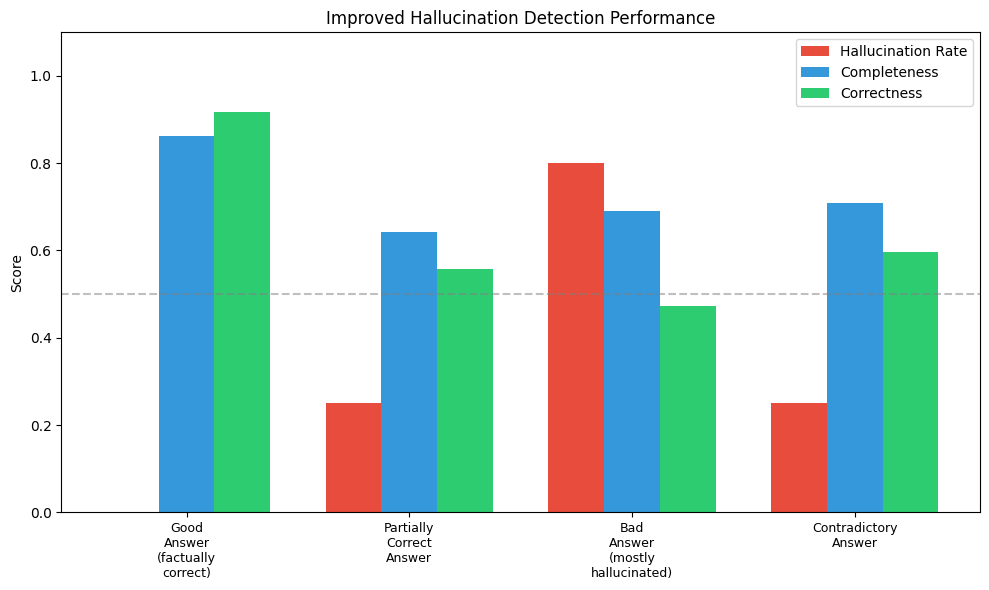

Saved: hallucination_detection.png


In [11]:
# Cell 11: Visualize hallucination detection results
fig, ax = plt.subplots(figsize=(10, 6))

names = [r['name'] for r in hallucination_results]
x = np.arange(len(names))
width = 0.25

bars1 = ax.bar(x - width, [r['hallucination_rate'] for r in hallucination_results],
               width, label='Hallucination Rate', color='#e74c3c')
bars2 = ax.bar(x, [r['completeness'] for r in hallucination_results],
               width, label='Completeness', color='#3498db')
bars3 = ax.bar(x + width, [r['correctness'] for r in hallucination_results],
               width, label='Correctness', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Improved Hallucination Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold')

plt.tight_layout()
plt.savefig('hallucination_detection.png', dpi=150)
plt.show()
print("Saved: hallucination_detection.png")

---
## 3. Spike Detection Metric Testing

In [12]:
# Cell 12: Test spike detection metrics
print("Spike Detection Metric Testing")
print("="*60)
print("\nSpike metrics measure how well uncertainty triggers align with")
print("positions where retrieval is actually needed.")
print()

# Test scenarios
spike_scenarios = [
    {
        "name": "Perfect Detection",
        "detected": [10, 25, 50, 75],
        "expected": [10, 25, 50, 75],
        "description": "All triggers exactly match expected positions",
    },
    {
        "name": "Good Detection (within tolerance)",
        "detected": [12, 24, 48, 77],
        "expected": [10, 25, 50, 75],
        "description": "Triggers within tolerance=3 of expected",
    },
    {
        "name": "Partial Detection (missed some)",
        "detected": [10, 50],
        "expected": [10, 25, 50, 75],
        "description": "Only detected 2 of 4 expected triggers",
    },
    {
        "name": "Over-triggering (false positives)",
        "detected": [10, 20, 25, 30, 50, 60, 75, 90],
        "expected": [10, 25, 50, 75],
        "description": "Detected all expected + 4 false positives",
    },
    {
        "name": "Poor Detection (misaligned)",
        "detected": [5, 35, 65, 95],
        "expected": [10, 25, 50, 75],
        "description": "Triggers far from expected positions",
    },
    {
        "name": "No Detection",
        "detected": [],
        "expected": [10, 25, 50, 75],
        "description": "System never triggered retrieval",
    },
]

spike_results = []
for scenario in spike_scenarios:
    precision = metrics.spike_precision(scenario['detected'], scenario['expected'])
    recall = metrics.spike_recall(scenario['detected'], scenario['expected'])
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    spike_results.append({
        'name': scenario['name'],
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

    print(f"{scenario['name']}:")
    print(f"  {scenario['description']}")
    print(f"  Detected: {scenario['detected']}")
    print(f"  Expected: {scenario['expected']}")
    print(f"  Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
    print()

Spike Detection Metric Testing

Spike metrics measure how well uncertainty triggers align with
positions where retrieval is actually needed.

Perfect Detection:
  All triggers exactly match expected positions
  Detected: [10, 25, 50, 75]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Good Detection (within tolerance):
  Triggers within tolerance=3 of expected
  Detected: [12, 24, 48, 77]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Partial Detection (missed some):
  Only detected 2 of 4 expected triggers
  Detected: [10, 50]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 0.500  F1: 0.667

Over-triggering (false positives):
  Detected all expected + 4 false positives
  Detected: [10, 20, 25, 30, 50, 60, 75, 90]
  Expected: [10, 25, 50, 75]
  Precision: 0.500  Recall: 1.000  F1: 0.667

Poor Detection (misaligned):
  Triggers far from expected positions
  Detected: [5, 35, 65, 95]
  Expected: [10, 25, 50, 75]
  Precision:

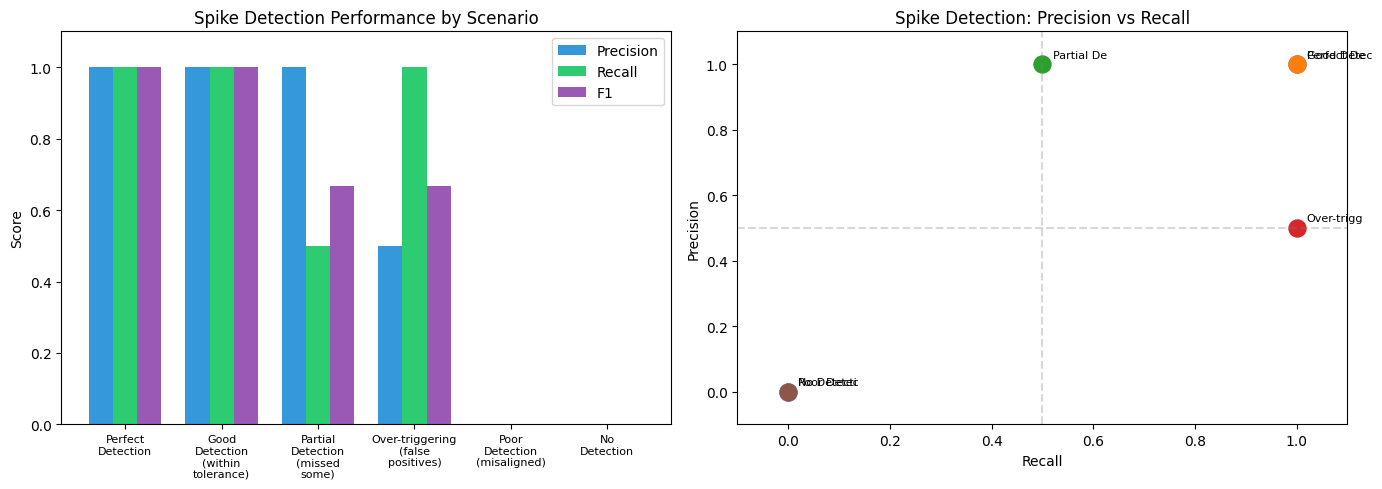

Saved: spike_detection.png


In [13]:
# Cell 13: Visualize spike detection results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
names = [r['name'].replace(' ', '\n') for r in spike_results]
x = np.arange(len(names))
width = 0.25

ax1.bar(x - width, [r['precision'] for r in spike_results], width, label='Precision', color='#3498db')
ax1.bar(x, [r['recall'] for r in spike_results], width, label='Recall', color='#2ecc71')
ax1.bar(x + width, [r['f1'] for r in spike_results], width, label='F1', color='#9b59b6')

ax1.set_ylabel('Score')
ax1.set_title('Spike Detection Performance by Scenario')
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=8)
ax1.legend()
ax1.set_ylim(0, 1.1)

# Precision-Recall scatter
ax2 = axes[1]
for i, r in enumerate(spike_results):
    ax2.scatter(r['recall'], r['precision'], s=150, label=r['name'][:15])
    ax2.annotate(r['name'][:10], (r['recall']+0.02, r['precision']+0.02), fontsize=8)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Spike Detection: Precision vs Recall')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('spike_detection.png', dpi=150)
plt.show()
print("Saved: spike_detection.png")

---
## 4. Load Model and Run Comprehensive Experiments

In [14]:
# Cell 14: Get mock codebase
documents = get_mock_codebase()

print(f"Mock Flask Application Codebase")
print("="*60)
print(f"Total files: {len(documents)}")
print(f"Total size: {sum(len(c) for c in documents.values()):,} characters")
print("\nFiles:")
for path in sorted(documents.keys()):
    print(f"  {path} ({len(documents[path]):,} chars)")

Mock Flask Application Codebase
Total files: 14
Total size: 22,395 characters

Files:
  src/api/middleware.py (1,564 chars)
  src/api/routes.py (2,424 chars)
  src/app.py (1,305 chars)
  src/auth/jwt.py (1,796 chars)
  src/auth/password.py (681 chars)
  src/config.py (1,870 chars)
  src/db/migrations.py (1,033 chars)
  src/db/models.py (2,804 chars)
  src/services/cache.py (1,660 chars)
  src/services/email.py (1,453 chars)
  src/utils/logging.py (1,522 chars)
  src/utils/validators.py (1,912 chars)
  tests/test_api.py (1,309 chars)
  tests/test_auth.py (1,062 chars)


In [15]:
# Cell 15: Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()

print(f"Model loaded on {model.device}")

Loading codellama/CodeLlama-7b-Instruct-hf...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded on cuda:0


In [16]:
# Cell 16: Import generation modules and configure CCE with FILE LIST approach
from orchestrator.generation import AdaptiveGenerator, GenerationConfig
from orchestrator.retrieval.adaptive import EmbeddingRetriever

# ============================================================================
# NEW APPROACH: File List Context
# ============================================================================
# Instead of giving CCE no context, we give it a list of available files.
# This allows the model's confused tokens to match against actual file names.
#
# Key insight: The model will produce tokens like "jwt", "password", "routes"
# when uncertain, which can now match against the file paths directly!

# Create file list context (very small - just paths, not content)
file_list = list(documents.keys())
file_list_context = """Available files in this codebase:
{}

When answering questions about this codebase, refer to the relevant files above.""".format(
    '\n'.join(f'- {f}' for f in file_list)
)

print("FILE LIST CONTEXT:")
print("-" * 40)
print(file_list_context)
print("-" * 40)
file_list_tokens = len(tokenizer.encode(file_list_context))
print(f"File list tokens: {file_list_tokens} (vs {sum(len(tokenizer.encode(c)) for c in documents.values()):,} for full content)")

# Create retriever with file list for topic inference
retriever = EmbeddingRetriever(documents, model_name='all-MiniLM-L6-v2')

# CCE CONFIGURATION
config = GenerationConfig(
    max_tokens=200,
    max_retrievals=5,
    uncertainty_threshold=3.0,   # Week 3 best
    cooldown_tokens=5,
    uncertainty_method="raw_entropy",
    measurement_strategy="every_token",
)

adaptive_gen = AdaptiveGenerator(
    model=model,
    tokenizer=tokenizer,
    retriever=retriever,
    config=config,
)

# CRITICAL: Pass file paths to topic inferrer for matching
adaptive_gen.topic_inferrer.set_available_files(file_list)

print()
print("AdaptiveGenerator configured with FILE LIST APPROACH:")
print(f"  uncertainty_threshold: {config.uncertainty_threshold}")
print(f"  max_retrievals: {config.max_retrievals}")
print(f"  cooldown_tokens: {config.cooldown_tokens}")
print()
print("NEW FEATURES:")
print("  1. File list as initial context (model sees available files)")
print("  2. Topic inferrer matches confused tokens against file paths")
print("  3. Retrieves files that match what model is uncertain about")
print()
print("EXPECTED IMPROVEMENT:")
print("  Model says 'jwt...' → matches 'src/auth/jwt.py' → retrieves correct file")

FILE LIST CONTEXT:
----------------------------------------
Available files in this codebase:
- src/auth/jwt.py
- src/auth/password.py
- src/api/routes.py
- src/api/middleware.py
- src/db/models.py
- src/db/migrations.py
- src/config.py
- src/services/email.py
- src/services/cache.py
- src/utils/validators.py
- src/utils/logging.py
- src/app.py
- tests/test_auth.py
- tests/test_api.py

When answering questions about this codebase, refer to the relevant files above.
----------------------------------------
File list tokens: 152 (vs 7,109 for full content)

AdaptiveGenerator configured with FILE LIST APPROACH:
  uncertainty_threshold: 3.0
  max_retrievals: 5
  cooldown_tokens: 5

NEW FEATURES:
  1. File list as initial context (model sees available files)
  2. Topic inferrer matches confused tokens against file paths
  3. Retrieves files that match what model is uncertain about

EXPECTED IMPROVEMENT:
  Model says 'jwt...' → matches 'src/auth/jwt.py' → retrieves correct file


In [17]:
# Cell 17: Create baseline runner
baseline_runner = BaselineRunner(
    model=model,
    tokenizer=tokenizer,
    documents=documents,
)

print("BaselineRunner configured")

BaselineRunner configured


In [18]:
# Cell 18: Run comprehensive experiments with FILE LIST CCE approach
# Select a subset of examples for faster evaluation
# (Use full benchmark for final experiments)

# Get balanced sample: 2 from each category
sample_examples = []
for cat in Category:
    filtered = benchmark.filter(category=cat)
    for i, ex in enumerate(filtered):
        if i < 2:  # 2 per category
            sample_examples.append(ex)

print(f"Running experiments on {len(sample_examples)} examples")
print(f"Categories covered: {len(set(ex.category for ex in sample_examples))}")

# Methods to evaluate
methods = [
    BaselineMethod.NO_CONTEXT,
    BaselineMethod.BM25,
    BaselineMethod.EMBEDDING,
    BaselineMethod.FULL_CONTEXT,
]

# Results storage
all_results = {m.value: [] for m in methods}
all_results['cce_adaptive'] = []

# CCE debug info
cce_debug = []

# Compute baseline tokens
baseline_tokens = sum(len(tokenizer.encode(c)) for c in documents.values())
print(f"Baseline tokens (full context): {baseline_tokens:,}")
print(f"File list tokens: {file_list_tokens}")
print()

# Run experiments
total = len(sample_examples) * (len(methods) + 1)  # +1 for CCE
current = 0

for i, example in enumerate(sample_examples):
    print(f"\nExample {i+1}/{len(sample_examples)}: {example.id}")
    print(f"  Category: {example.category.value}")
    print(f"  Query: {example.query[:50]}...")

    # Run baselines
    for method in methods:
        current += 1
        print(f"  Running {method.value}... ({current}/{total})")

        result = baseline_runner.run(example, method, max_tokens=200)

        eval_result = metrics.evaluate(
            example_id=example.id,
            generated_answer=result['answer'],
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=result['retrieved_files'],
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=result['tokens_used'],
            baseline_tokens=baseline_tokens,
            generation_time=result['generation_time'],
            num_retrievals=result['num_retrievals'],
            method=method.value,
        )
        eval_result.metadata['category'] = example.category.value
        eval_result.metadata['difficulty'] = example.difficulty.value

        all_results[method.value].append(eval_result)

    # Run CCE adaptive WITH FILE LIST CONTEXT
    current += 1
    print(f"  Running cce_adaptive (FILE LIST)... ({current}/{total})")

    try:
        # Reset retriever for new generation
        retriever.reset()

        # Generate with FILE LIST as initial context
        gen_result = adaptive_gen.generate(
            query=example.query,
            initial_context=file_list_context,  # NEW: File list instead of empty!
        )

        # Debug: log CCE behavior
        debug_info = {
            'example_id': example.id,
            'total_retrievals': gen_result.total_retrievals,
            'context_sources': gen_result.context_sources,
            'total_context_tokens': gen_result.total_context_tokens,
            'response_length': len(gen_result.response),
        }
        cce_debug.append(debug_info)

        # Get matched files from topic inferrer history
        if adaptive_gen.topic_inferrer.history:
            last_topic = adaptive_gen.topic_inferrer.history[-1]
            debug_info['matched_files'] = last_topic.matched_files
            debug_info['search_terms'] = last_topic.metadata.get('search_terms', [])

        # Print CCE debug info
        print(f"    CCE triggered {gen_result.total_retrievals} retrievals")
        print(f"    Retrieved files: {gen_result.context_sources}")
        if 'matched_files' in debug_info:
            print(f"    Matched by tokens: {debug_info['matched_files']}")

        cce_eval = metrics.evaluate(
            example_id=example.id,
            generated_answer=gen_result.response,
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=gen_result.context_sources,
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=gen_result.total_context_tokens + file_list_tokens,  # Include file list
            baseline_tokens=baseline_tokens,
            generation_time=gen_result.generation_time,
            num_retrievals=gen_result.total_retrievals,
            method='cce_adaptive',
        )
        cce_eval.metadata['category'] = example.category.value
        cce_eval.metadata['difficulty'] = example.difficulty.value
        all_results['cce_adaptive'].append(cce_eval)
    except Exception as e:
        print(f"  CCE error: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("Experiments Complete!")
print("="*60)

# Print CCE summary
print("\nCCE RETRIEVAL SUMMARY (FILE LIST APPROACH):")
print("-"*40)
total_retrievals = sum(d['total_retrievals'] for d in cce_debug)
avg_retrievals = total_retrievals / len(cce_debug) if cce_debug else 0
print(f"Total retrievals across all examples: {total_retrievals}")
print(f"Average retrievals per example: {avg_retrievals:.1f}")
print(f"File list overhead: {file_list_tokens} tokens")

Running experiments on 12 examples
Categories covered: 6
Baseline tokens (full context): 7,109
File list tokens: 152


Example 1/12: arch_001
  Category: architecture
  Query: What is the overall structure of the Flask applica...
  Running no_context... (1/60)
  Running bm25... (2/60)
  Running embedding... (3/60)
  Running full_context... (4/60)
  Running cce_adaptive (FILE LIST)... (5/60)
    CCE triggered 5 retrievals
    Retrieved files: ['initial', 'query', 'src/app.py', 'src/utils/logging.py', 'src/auth/password.py', 'src/db/migrations.py', 'src/config.py']
    Matched by tokens: ['src/auth/password.py', 'src/db/models.py', 'src/auth/jwt.py']

Example 2/12: arch_002
  Category: architecture
  Query: How does the authentication system work in this ap...
  Running no_context... (6/60)
  Running bm25... (7/60)
  Running embedding... (8/60)
  Running full_context... (9/60)
  Running cce_adaptive (FILE LIST)... (10/60)
    CCE triggered 3 retrievals
    Retrieved files: ['initial', 'q

In [19]:
# Cell 19: Aggregate results
print("Aggregate Results")
print("="*70)

aggregates = {}
for method, results in all_results.items():
    if results:
        aggregates[method] = metrics.aggregate_results(results)

# Create comparison table
comparison_data = []
for method, agg in aggregates.items():
    row = {
        'Method': method,
        'Correctness': agg['metrics']['answer_correctness']['mean'],
        'Completeness': agg['metrics']['answer_completeness']['mean'],
        'Hallucination': agg['metrics']['hallucination_rate']['mean'],
        'Context P': agg['metrics']['context_precision']['mean'],
        'Context R': agg['metrics']['context_recall']['mean'],
        'Efficiency': agg['metrics']['token_efficiency']['mean'],
        'Composite': agg['metrics']['composite_score']['mean'],
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Composite', ascending=False)

print(df_comparison.to_string(index=False, float_format='{:.3f}'.format))

Aggregate Results
      Method  Correctness  Completeness  Hallucination  Context P  Context R  Efficiency  Composite
   embedding        0.566         0.628          0.579      0.361      0.757       0.794      0.575
        bm25        0.542         0.613          0.637      0.361      0.639       0.739      0.539
  no_context        0.357         0.486          0.592      0.000      0.000       0.999      0.423
cce_adaptive        0.289         0.414          0.550      0.147      0.479       0.762      0.406
full_context        0.044         0.064          0.988      0.125      1.000       0.000      0.077


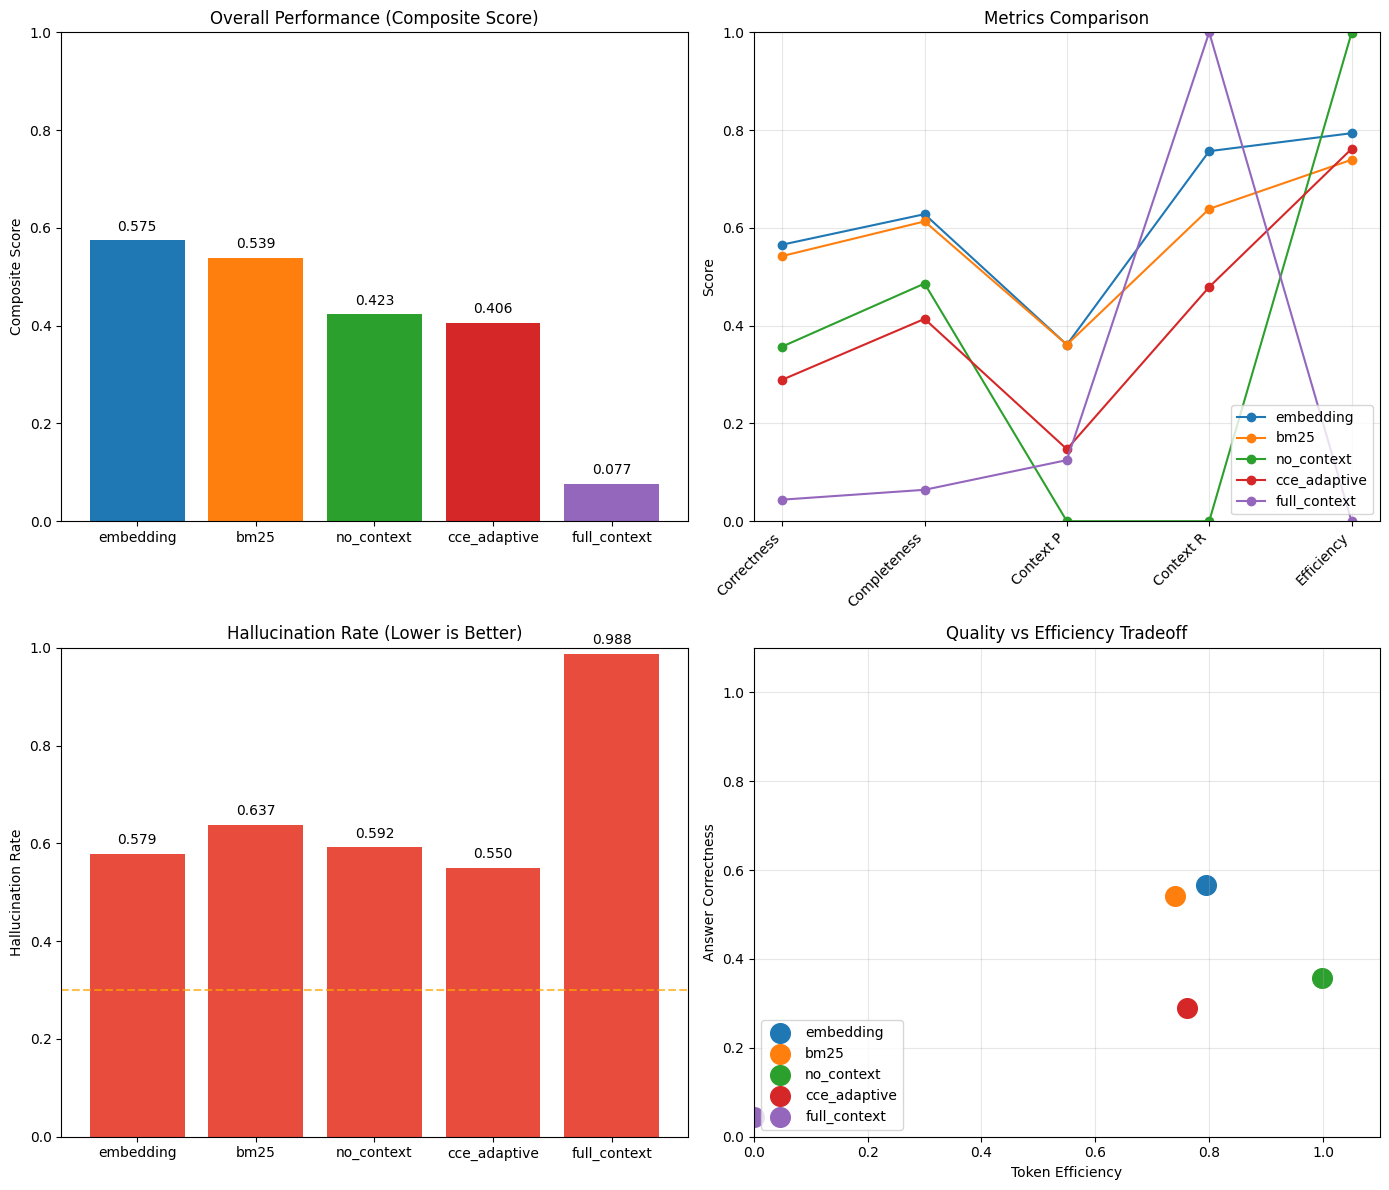

Saved: comprehensive_results.png


In [20]:
# Cell 20: Visualize comprehensive results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods_order = df_comparison['Method'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Composite scores
ax1 = axes[0, 0]
bars = ax1.bar(methods_order, df_comparison['Composite'], color=colors[:len(methods_order)])
ax1.set_ylabel('Composite Score')
ax1.set_title('Overall Performance (Composite Score)')
ax1.set_ylim(0, 1)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 2. Metric comparison radar-style
ax2 = axes[0, 1]
metric_cols = ['Correctness', 'Completeness', 'Context P', 'Context R', 'Efficiency']
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    values = [row[m] for m in metric_cols]
    ax2.plot(metric_cols, values, 'o-', label=method, color=colors[i % len(colors)])
ax2.set_ylabel('Score')
ax2.set_title('Metrics Comparison')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Hallucination rate (lower is better)
ax3 = axes[1, 0]
halluc_values = df_comparison['Hallucination'].tolist()
bars3 = ax3.bar(methods_order, halluc_values, color=['#e74c3c' if v > 0.3 else '#2ecc71' for v in halluc_values])
ax3.set_ylabel('Hallucination Rate')
ax3.set_title('Hallucination Rate (Lower is Better)')
ax3.set_ylim(0, 1)
ax3.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, label='Threshold')
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 4. Efficiency vs Quality tradeoff
ax4 = axes[1, 1]
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    ax4.scatter(row['Efficiency'], row['Correctness'], s=200,
                color=colors[i % len(colors)], label=method)
ax4.set_xlabel('Token Efficiency')
ax4.set_ylabel('Answer Correctness')
ax4.set_title('Quality vs Efficiency Tradeoff')
ax4.legend(loc='lower left')
ax4.set_xlim(0, 1.1)
ax4.set_ylim(0, 1.1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_results.png', dpi=150)
plt.show()
print("Saved: comprehensive_results.png")

In [21]:
# Cell 21: Results by category
print("Results by Category")
print("="*70)

# Organize results by category
results_by_category = defaultdict(lambda: defaultdict(list))

for method, results in all_results.items():
    for r in results:
        cat = r.metadata.get('category', 'unknown')
        results_by_category[cat][method].append(r.get_composite_score())

# Create category comparison table
cat_data = []
for cat in Category:
    row = {'Category': cat.value}
    for method in ['no_context', 'bm25', 'embedding', 'full_context', 'cce_adaptive']:
        scores = results_by_category[cat.value].get(method, [])
        row[method] = np.mean(scores) if scores else 0.0
    cat_data.append(row)

df_category = pd.DataFrame(cat_data)
print(df_category.to_string(index=False, float_format='{:.3f}'.format))

Results by Category
      Category  no_context  bm25  embedding  full_context  cce_adaptive
  architecture       0.440 0.564      0.711         0.048         0.394
     api_usage       0.448 0.534      0.600         0.048         0.394
implementation       0.454 0.610      0.629         0.089         0.494
     debugging       0.345 0.383      0.418         0.099         0.481
 configuration       0.441 0.536      0.607         0.063         0.281
     data_flow       0.411 0.607      0.483         0.113         0.393


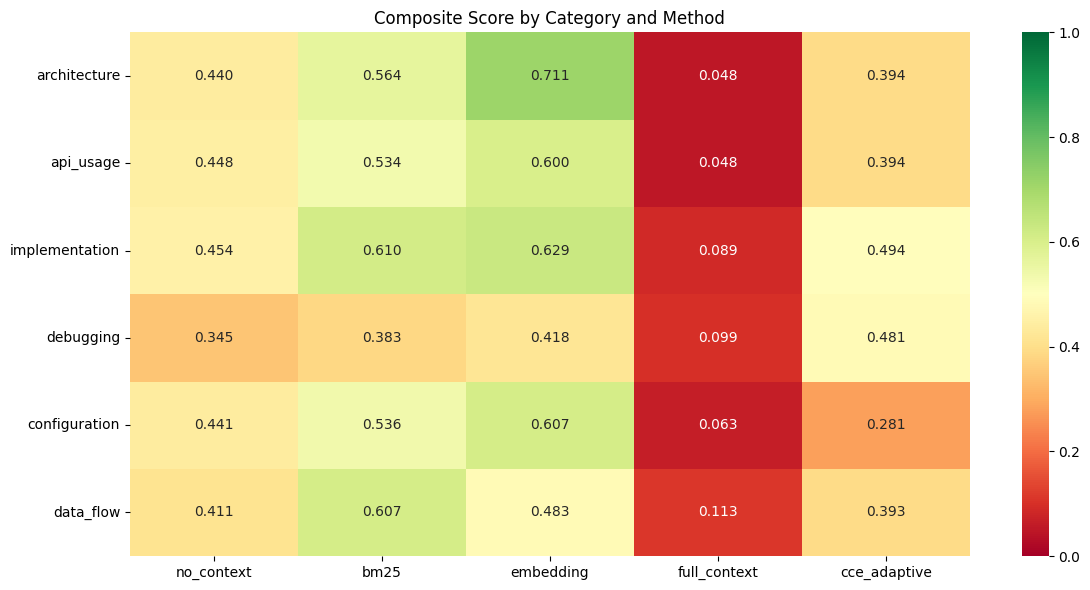

Saved: category_heatmap.png


In [22]:
# Cell 22: Category heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for heatmap
method_cols = [c for c in df_category.columns if c != 'Category']
heatmap_data = df_category[method_cols].values

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=method_cols,
    yticklabels=df_category['Category'],
    ax=ax,
    vmin=0,
    vmax=1,
)

ax.set_title('Composite Score by Category and Method')
plt.tight_layout()
plt.savefig('category_heatmap.png', dpi=150)
plt.show()
print("Saved: category_heatmap.png")

In [23]:
# Cell 23: Statistical significance testing
from scipy import stats

print("Statistical Significance Testing")
print("="*70)
print("\nComparing CCE Adaptive against baselines (paired t-test)")
print()

cce_scores = [r.get_composite_score() for r in all_results.get('cce_adaptive', [])]

if cce_scores:
    for method in ['no_context', 'bm25', 'embedding', 'full_context']:
        baseline_scores = [r.get_composite_score() for r in all_results.get(method, [])]

        if len(baseline_scores) == len(cce_scores):
            t_stat, p_value = stats.ttest_rel(cce_scores, baseline_scores)
            mean_diff = np.mean(cce_scores) - np.mean(baseline_scores)

            print(f"CCE vs {method}:")
            print(f"  Mean difference: {mean_diff:+.3f}")
            print(f"  t-statistic: {t_stat:.3f}")
            print(f"  p-value: {p_value:.4f}")
            print(f"  Significant (p<0.05): {'Yes' if p_value < 0.05 else 'No'}")
            print()
else:
    print("No CCE results available for comparison")

Statistical Significance Testing

Comparing CCE Adaptive against baselines (paired t-test)

CCE vs no_context:
  Mean difference: -0.017
  t-statistic: -0.257
  p-value: 0.8022
  Significant (p<0.05): No

CCE vs bm25:
  Mean difference: -0.133
  t-statistic: -2.750
  p-value: 0.0189
  Significant (p<0.05): Yes

CCE vs embedding:
  Mean difference: -0.168
  t-statistic: -3.013
  p-value: 0.0118
  Significant (p<0.05): Yes

CCE vs full_context:
  Mean difference: +0.330
  t-statistic: 9.181
  p-value: 0.0000
  Significant (p<0.05): Yes



---
## 5. Summary and Export

In [24]:
# Cell 24: Summary
print("="*70)
print("WEEK 8 COMPREHENSIVE EVALUATION (v4 - FILE LIST APPROACH)")
print("="*70)

print('''
NEW APPROACH: FILE LIST CONTEXT
================================

Instead of giving CCE empty context, we provide a list of available files.
This allows the model to:
1. Know what files exist in the codebase
2. Produce confusion tokens that match actual file names
3. Retrieve targeted files based on uncertainty

How it works:
  Model generates: "JWT tokens are created using..."
  Model gets uncertain about: "jwt", "token", "create"
  Topic inferrer matches: "jwt" → src/auth/jwt.py
  Retrieves: src/auth/jwt.py (correct file!)

vs Previous approach:
  Model generates: "JWT tokens are created using..."
  Model gets uncertain about: "jwt", "token", "create"
  Topic inferrer builds query: "flask api jwt token"
  Embedding search: → middleware.py (wrong file!)

CCE CONFIGURATION:
  uncertainty_threshold: 3.0   (Week 3 best, F1=0.941)
  max_retrievals: 5
  cooldown_tokens: 5
  initial_context: FILE LIST (~100 tokens)
  retriever: EmbeddingRetriever + file path matching

BASELINE COMPARISON:
  - EMBEDDING: 1 retrieval × 3 files = 3 files upfront
  - CCE: File list (~100 tokens) + retrieves only what model needs
''')

# Print best method
if not df_comparison.empty:
    best = df_comparison.iloc[0]
    print(f"BEST METHOD: {best['Method']}")
    print(f"  Composite Score: {best['Composite']:.3f}")
    print(f"  Correctness: {best['Correctness']:.3f}")
    print(f"  Efficiency: {best['Efficiency']:.3f}")

print("\nCCE ADAPTIVE RETRIEVAL DETAILS:")
if 'cce_debug' in dir() and cce_debug:
    total_ret = sum(d['total_retrievals'] for d in cce_debug)
    avg_ret = total_ret / len(cce_debug)
    print(f"  Average retrievals per example: {avg_ret:.1f}")
    print(f"  File list overhead: {file_list_tokens} tokens")

    # Count unique files retrieved
    all_sources = []
    for d in cce_debug:
        all_sources.extend([s for s in d['context_sources'] if s != 'query'])
    unique_sources = set(all_sources)
    print(f"  Unique files retrieved: {len(unique_sources)}")
    print()

    # Show matched files for each example
    print("  Retrieval details:")
    for d in cce_debug:
        sources = [s for s in d['context_sources'] if s != 'query']
        matched = d.get('matched_files', [])
        print(f"  {d['example_id']}: {d['total_retrievals']} retrievals")
        print(f"    Retrieved: {sources}")
        if matched:
            print(f"    Matched by tokens: {matched}")

WEEK 8 COMPREHENSIVE EVALUATION (v4 - FILE LIST APPROACH)

NEW APPROACH: FILE LIST CONTEXT

Instead of giving CCE empty context, we provide a list of available files.
This allows the model to:
1. Know what files exist in the codebase
2. Produce confusion tokens that match actual file names
3. Retrieve targeted files based on uncertainty

How it works:
  Model generates: "JWT tokens are created using..."
  Model gets uncertain about: "jwt", "token", "create"
  Topic inferrer matches: "jwt" → src/auth/jwt.py
  Retrieves: src/auth/jwt.py (correct file!)

vs Previous approach:
  Model generates: "JWT tokens are created using..."
  Model gets uncertain about: "jwt", "token", "create"
  Topic inferrer builds query: "flask api jwt token"
  Embedding search: → middleware.py (wrong file!)

CCE CONFIGURATION:
  uncertainty_threshold: 3.0   (Week 3 best, F1=0.941)
  max_retrievals: 5
  cooldown_tokens: 5
  initial_context: FILE LIST (~100 tokens)
  retriever: EmbeddingRetriever + file path matchi

In [25]:
# Cell 25: Export results
results_export = {
    'version': 'v4_file_list_approach',
    'config': {
        'max_retrievals': 5,
        'cooldown_tokens': 5,
        'uncertainty_threshold': 3.0,
        'initial_context': 'file_list',  # NEW!
        'file_list_tokens': file_list_tokens,
        'retriever': 'EmbeddingRetriever',
        'file_path_matching': True,  # NEW!
        'deduplication': True,
    },
    'comparison_table': df_comparison.to_dict('records'),
    'category_results': df_category.to_dict('records'),
    'hallucination_tests': hallucination_results,
    'spike_detection_tests': spike_results,
    'cce_debug': cce_debug if 'cce_debug' in dir() else [],
}

with open('week8_results_v4.json', 'w') as f:
    json.dump(results_export, f, indent=2, default=str)

print("Results exported to week8_results_v4.json")

# Download files
try:
    from google.colab import files
    for fname in ['benchmark_distribution.png', 'hallucination_detection.png',
                  'spike_detection.png', 'comprehensive_results.png',
                  'category_heatmap.png', 'week8_results_v4.json']:
        if os.path.exists(fname):
            files.download(fname)
except:
    print("Download files manually or run locally")

Results exported to week8_results_v4.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>